## Obtain the Antenna S11 for EDGES-3

In [1]:
import hickle
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as un
from edges_analysis.calibration.s11 import AntennaS11
from edges_cal import modelling as mdl
from edges_cal.tools import FrequencyRange
#from edges_pipelines import DATA
from edges_cal.alanmode import read_s11_csv, read_spec_txt, read_specal, reads1p1


In [2]:
ea_dir: str = "/data4/vydula/edges/edges3-data-analysis/scripts/prefect-10days"
alan_dir: str = "/data4/vydula/edges/edges3-data-analysis/scripts/alan_300_310_tests/"

data_dir: str = '/data5/edges/data/EDGES3_data/MRO'

ant_s11_year : 2022
ant_s11_day : 319
    


In [3]:
#reads1p1 using alanmode:

raw_freq, ea_ant_s11 = reads1p1(
    res = 49.930,
    Tfopen = f'{data_dir}/2023_286_15_O.s1p',
    Tfshort = f'{data_dir}/2023_286_15_S.s1p',
    Tfload = f'{data_dir}/2023_286_15_L.s1p',
    Tfant = f'{data_dir}/2023_286_15_ant.s1p',
    
    
);

ea_ant_s11 = ea_ant_s11.value
raw_freq = raw_freq.value

#use 53-105 MHz --> Alan sets wfstart/stop to 54-104 MHz but also hardcodes /pm 1 to it
ea_freq = FrequencyRange(f=raw_freq*un.Hz, f_low = 53*un.MHz, f_high =105*un.MHz)

In [4]:
#raw ant s11 Alan
alan_freq, alan_ant_s11 = read_s11_csv(f'{alan_dir}/s11ant286t.csv')

#modelled S11
data = np.loadtxt(f'{alan_dir}/ant_s11_modelled.txt', comments='#')

alan_m_freq = data[:, 0]  # Frequency values are in the first column

alan_m_ant_s11 = data[:, 1] + 1j * data[:, 2]


ants11 = AntennaS11(
    raw_s11=ea_ant_s11[ea_freq.mask],
    freq = ea_freq,
    n_terms= 12, #nfit4
    model_type = mdl.Polynomial, # Use polynominal when n_terms <16
    complex_model_type = mdl.ComplexRealImagModel, # Fit on real/imag instead of abs/phase
    model_transform = mdl.Log10Transform(scale= (alan_m_freq[0] + alan_m_freq[-1])/2),
    set_transform_range = True,
    fit_kwargs ={"method": "alan-qrd"},
    internal_switch = None,
).with_model_delay()

In [5]:
ants11.model_delay

<Quantity 0.0208 us>

In [6]:
ea_m_ant_s11 = ants11.s11_model(data[:, 0] * un.MHz)

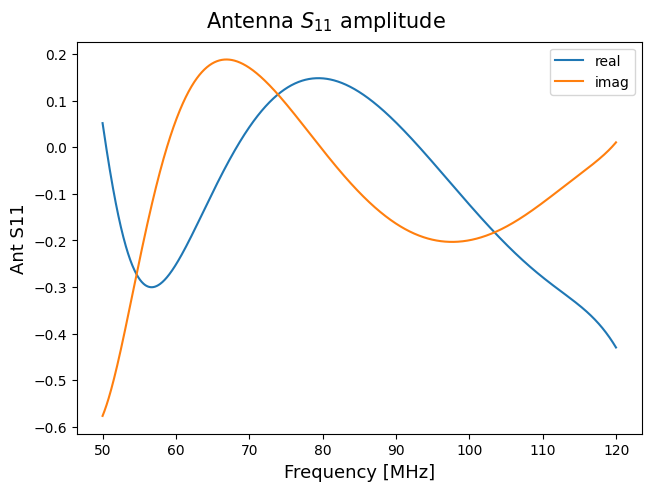

In [7]:
fig, ax = plt.subplots(1, 1, sharex=True, constrained_layout=True, gridspec_kw={'hspace': 0})


ax.plot(data[:, 0], ea_m_ant_s11.real, label='real')
ax.plot(data[:, 0], ea_m_ant_s11.imag, label='imag')

plt.legend()
ax.set_xlabel("Frequency [MHz]", fontsize=13)
ax.set_ylabel("Ant S11", fontsize=13)
fig.suptitle("Antenna $S_{11}$ amplitude", fontsize=15);

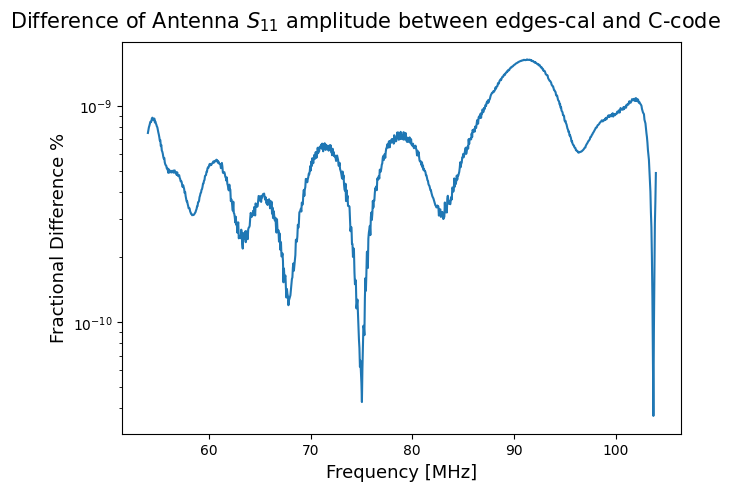

In [8]:
fig, ax = plt.subplots(1, 1, sharex=True, constrained_layout=True, gridspec_kw={'hspace': 0})
plot_mask = (alan_m_freq>54) & (alan_m_freq < 104)


ax.plot(data[:, 0][plot_mask], (100*np.abs(alan_m_ant_s11 - ea_m_ant_s11)/np.abs(ea_m_ant_s11))[plot_mask])
ax.set_yscale('log')

ax.set_xlabel("Frequency [MHz]", fontsize=13)
ax.set_ylabel("Fractional Difference %", fontsize=13)
fig.suptitle("Difference of Antenna $S_{11}$ amplitude between edges-cal and C-code", fontsize=15);

In [9]:
hickle.dump(ants11, f"{ea_dir}/ants11_modelled.h5")

/home/vydula/src/anaconda/envs/prefect-edges/lib/python3.11/site-packages/hickle/lookup.py:1491: SerializedWarning: 'slice' type not understood, data is serialized:
  warnings.warn(
/home/vydula/src/anaconda/envs/prefect-edges/lib/python3.11/site-packages/hickle/lookup.py:1491: SerializedWarning: 'ABCMeta' type not understood, data is serialized:
  warnings.warn(
/home/vydula/src/anaconda/envs/prefect-edges/lib/python3.11/site-packages/hickle/lookup.py:1491: SerializedWarning: 'YAMLObjectMetaclass' type not understood, data is serialized:
  warnings.warn(
